In [26]:
%load_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Feature 1: basic operations and stats for the reference ceRNA network

In [51]:
%autoreload

from cernatax.cernatax import CERNATAX

# initialize CERNATAX object
cernatax = CERNATAX()

# show CERNATAX reference ceRNA network
print(cernatax.summarize_ref_db())

# extract the CERNATAX reference ceRNA network 
ref_db = cernatax.ref_db

# there are some operations to filter the ceRNA interactions from the ref_db

# show reference interaction source
print(ref_db.database.value_counts())

# store the miRNA-mRNA;miRNA-lncRNA interactions
cernatax.ref_db[cernatax.ref_db.type == 'miRNA-mRNA;miRNA-lncRNA'].to_csv('ceRNA_db_mix.csv')

print('The number of unique ceRNA interactions: ', len(ref_db.ceRNA.unique()))
print('The number of unique miRNA-mRNA interactions: ', len(ref_db[ref_db.type == 'miRNA-mRNA'].ceRNA.unique()))
print('The number of unique miRNA-lncRNA interactions: ', len(ref_db[ref_db.type == 'miRNA-lncRNA'].ceRNA.unique()))

A total of 7820904 miRNA-mRNA interaction and 176510 miRNA-lncRNA interaction
type
miRNA-mRNA                 7820904
miRNA-lncRNA                176510
miRNA-mRNA;miRNA-lncRNA      10915
Name: count, dtype: int64
None
database
miRWalk                                                                 6494557
RNAInter                                                                 425707
miRDB_6.0                                                                297889
RNAInter;miRTarBase_9.0                                                  252458
NPInter_4.0                                                              109142
                                                                         ...   
miRDB_6.0;RNAInter;ENCORI                                                     2
miRDB_6.0;ENCORI                                                              2
RNAInter;miRWalk;ENCORI                                                       2
miRDB_6.0;NPInter_4.0;miRTarBase_9.0                

### Feature 2: Use differential expressed (DE) miRNA/mRNA to get cohort-specific and disease relatated ceRNA axis

In [52]:
%autoreload

# Use DE miRNA/mRNA to get the ceRNA_axis

import pandas as pd

# use DE miRNA list as the strict criteria
deg_strict_df = pd.read_csv('../scz_deg_gene_strict.csv', index_col=0)
print('deg_strict_df\n', deg_strict_df.head())
# use DE mRNA list as the loose criteria
deg_loose_df = pd.read_csv('../scz_deg_mRNA_loose.csv', index_col=0)
print('deg_loose_df\n', deg_loose_df.head())

# Use strict DE miRNA to get the ceRNA_axis
ceRNA_df, axis_df = cernatax.find_ceRNA_axis_by_DEG(deg_strict_df)
# store the filtered ceRNA network and ceRNA axis
ceRNA_df.to_csv('SCZ_ceRNA_network.csv')
axis_df.to_csv('SCZ_ceRNA_axis.csv')

# Use strict DE miRNA and loose DE mRNA to get the final ceRNA_axis
loose_axis_df = cernatax.expand_ceRNA_axis_by_loose_DEG(deg_strict_df, deg_loose_df)
# store the final ceRNA axis
loose_axis_df.to_csv('SCZ_ceRNA_loose_axis.csv')
# output the final ceRNA axis
loose_axis_df

deg_strict_df
                   type             gene    log2FC        pvalue          padj
hsa-miR-16-2-3p  miRNA  hsa-miR-16-2-3p -5.139793  2.640000e-13  4.020000e-10
hsa-miR-1306-3p  miRNA  hsa-miR-1306-3p -2.209798  3.320000e-11  1.690000e-08
hsa-miR-1307-3p  miRNA  hsa-miR-1307-3p -2.093602  2.960000e-11  1.690000e-08
hsa-miR-132-5p   miRNA   hsa-miR-132-5p -2.121375  5.510000e-09  1.680000e-06
hsa-miR-624-5p   miRNA   hsa-miR-624-5p  3.021188  3.580000e-08  9.100000e-06
deg_loose_df
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj  \
MPO      306.948587        2.216337  0.564877  3.923577  0.000087  0.002920   
DEPDC1    13.781165        2.521829  0.955832  2.638359  0.008331  0.072875   
DEPDC1B   35.058035        1.846581  0.528130  3.496453  0.000471  0.010010   
UTS2     166.152947        2.148164  0.747088  2.875383  0.004035  0.044262   
COL17A1   17.798800        2.779151  1.039143  2.674463  0.007485  0.067760   

            gene  type    lo

,miRNA,ceRNA,species,database,type,miRNA_log2FC,ceRNA_log2FC,inference
1775644,hsa-miR-3064-5p,ARHGAP8,Homo sapiens,miRWalk,miRNA-mRNA,-2.123515,5.218091,loose
1775806,hsa-miR-3064-5p,BCL2A1,Homo sapiens,miRWalk,miRNA-mRNA,-2.123515,1.586707,loose
1775833,hsa-miR-3064-5p,BIRC5,Homo sapiens,miRWalk,miRNA-mRNA,-2.123515,1.762193,loose
1775877,hsa-miR-3064-5p,BTNL3,Homo sapiens,miRWalk,miRNA-mRNA,-2.123515,4.612546,loose
1776086,hsa-miR-3064-5p,CCDC80,Homo sapiens,TargetSCAN_8.0,miRNA-mRNA,-2.123515,5.326842,loose
...,...,...,...,...,...,...,...,...
4495205,hsa-miR-485-5p,TLCD4-RWDD3,Homo sapiens,miRWalk,miRNA-mRNA,-3.818348,3.067442,loose
4495575,hsa-miR-485-5p,UNC5B,Homo sapiens,TargetSCAN_8.0,miRNA-mRNA,-3.818348,1.507402,loose
4495619,hsa-miR-485-5p,UTS2,Homo sapiens,miRWalk,miRNA-mRNA,-3.818348,2.148164,loose
4495817,hsa-miR-485-5p,ZFP30,Homo sapiens,miRWalk,miRNA-mRNA,-3.818348,1.746945,loose


### Feature 3: ceRNA expression visualization for a cohort

[[2457    0    0 ... 1179    8 1039]
 [2662    0    0 ... 1462    3 1412]
 [2395    0    0 ... 1372    2 2603]
 ...
 [4437    0    0 ... 1736    0 1187]
 [4113    0    0 ... 1922    2  669]
 [2746    0    0 ... 1298    0 1708]]
             type
Case-A52      SCZ
Case-A53      SCZ
Case-A54      SCZ
Case-A55      SCZ
Case-A56      SCZ
Case-A58      SCZ
Con-B02   Control
Con-B04   Control
Con-B08   Control
Con-B21   Control
Con-B22   Control


/Users/chenlingxi/miniconda3/envs/cospa/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


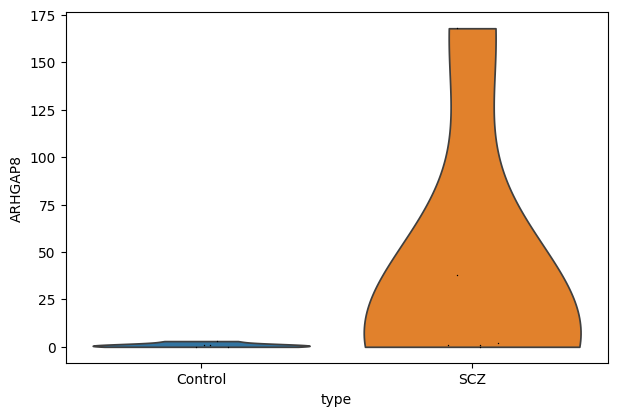

In [94]:
%autoreload
'''
Given the mRNA expression profiles for a cohort, plot the disease and control expression 
for the ceRNA axis
'''

import scanpy as sc

# Read one mRNA expression profiles from a SCZ cohort;
# this could be self-sequenced, or downloaded from the public GEO resources;
# the expression and phenotype information should be curated.
mRNA_adata = sc.read_h5ad('../mRNA_adata.h5ad')
mRNA_adata.var_names_make_unique()
# show the expression profile
print(mRNA_adata.X)
# show the phenotype information
print(mRNA_adata.obs)

# set the groupby as the cohort sample type
groupby = 'type'
# set the ceRNAs to be plotted
ceRNA_list = ['ARHGAP8']
# plot the expression of ceRNA_list
cernatax.plot_cohort_ceRNA_exp(mRNA_adata, groupby, ceRNA_list)


[[   296  71449    671 ...      0      3      2]
 [   292 164761    304 ...      0      0      7]
 [   641  41266   1013 ...      0      2      5]
 ...
 [  1119 159204    612 ...      5      0     17]
 [    86  11125    596 ...      2      1      5]
 [   235   6160    311 ...      1      1      1]]
             type
Case-A52      SCZ
Case-A53      SCZ
Case-A54      SCZ
Case-A55      SCZ
Case-A56      SCZ
Case-A58      SCZ
Con-B02   Control
Con-B04   Control
Con-B08   Control
Con-B21   Control
Con-B22   Control


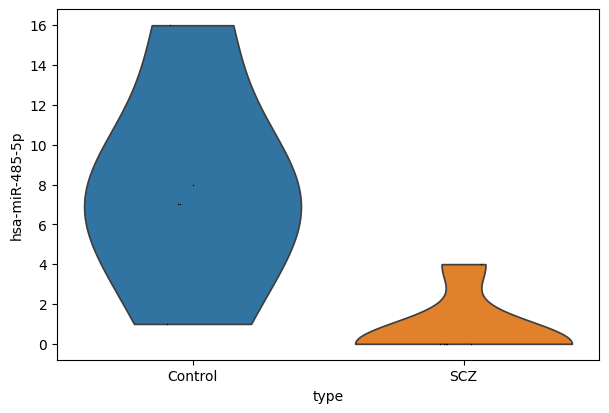

In [95]:
%autoreload
'''
Given the miRNA expression profiles for a cohort, plot the disease and control expression 
for the ceRNA axis
'''

import scanpy as sc

# Read one miRNA expression profiles from a SCZ cohort;
# this could be self-sequenced, or downloaded from the public GEO resources;
# the expression and phenotype information should be curated.
miRNA_adata = sc.read_h5ad('../miRNA_adata.h5ad')
miRNA_adata.var_names_make_unique()
# show the expression profile
print(miRNA_adata.X)
# show the phenotype information
print(miRNA_adata.obs)

# set the groupby as the cohort sample type
groupby = 'type'
# set the ceRNAs to be plotted
ceRNA_list = ['hsa-miR-485-5p']
# plot the expression of ceRNA_list
cernatax.plot_cohort_ceRNA_exp(miRNA_adata, groupby, ceRNA_list)


[[  7 239 461 ...   0   0   0]
 [  2 179   0 ...   0   0   0]
 [  0 245  47 ...   0   0   0]
 ...
 [  4 358  55 ...   0   0  33]
 [  2 151 390 ...   0   0   0]
 [  4 200 720 ...   0   0   0]]
             type
Case-A52      SCZ
Case-A53      SCZ
Case-A54      SCZ
Case-A55      SCZ
Case-A56      SCZ
Case-A58      SCZ
Con-B02   Control
Con-B04   Control
Con-B08   Control
Con-B21   Control
Con-B22   Control
Empty DataFrame
Columns: []
Index: [MSTRG.28358.1, MSTRG.237443.17, MSTRG.179162.5, MSTRG.131155.57, MSTRG.13892.1, MSTRG.18103.1, MSTRG.150011.4, MSTRG.179203.18, MSTRG.179203.17, MSTRG.248634.2, MSTRG.91062.1, MSTRG.101134.47, MSTRG.101134.42, MSTRG.101134.43, MSTRG.250407.11, MSTRG.4153.1, MSTRG.121055.1, MSTRG.61988.75, MSTRG.61988.71, MSTRG.61988.73, MSTRG.69751.1, MSTRG.43259.3, MSTRG.242363.20, MSTRG.256783.1, MSTRG.91376.4, MSTRG.91376.5, MSTRG.98121.1, MSTRG.66143.9, MSTRG.158321.2, MSTRG.132958.5, MSTRG.132958.4, MSTRG.132958.7, MSTRG.132958.6, MSTRG.64024.92, MSTRG.64024.94,

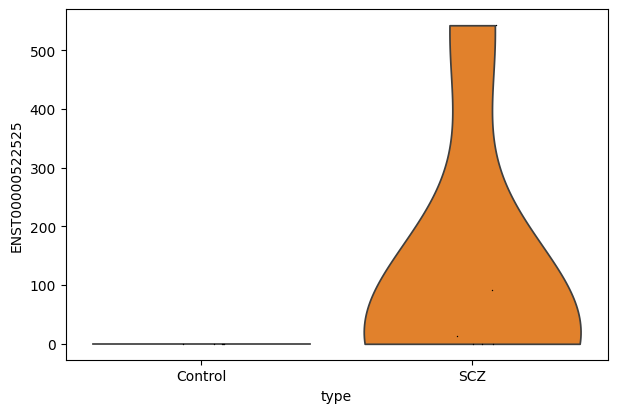

In [96]:
%autoreload
'''
Given the lncRNA expression profiles for a cohort, plot the disease and control expression 
for the ceRNA axis
'''

import scanpy as sc

# Read one lncRNA expression profiles from a SCZ cohort;
# this could be self-sequenced, or downloaded from the public GEO resources;
# the expression and phenotype information should be curated.
lncRNA_adata = sc.read_h5ad('../lncRNA_adata.h5ad')
lncRNA_adata.var_names_make_unique()
# show the expression profile
print(lncRNA_adata.X)
# show the phenotype information
print(lncRNA_adata.obs)
print(lncRNA_adata.var)
# set the groupby as the cohort sample type
groupby = 'type'
# set the ceRNAs to be plotted
ceRNA_list = ['ENST00000522525'] # the ens id of 'THUMPD3-AS1'
# plot the expression of ceRNA_list
cernatax.plot_cohort_ceRNA_exp(lncRNA_adata, groupby, ceRNA_list)


### Feature 4: ceRNA-axis correlation analysis for a cohort

In [100]:
%autoreload

import anndata as ad
# merge the mRNA, miRNA, and lncRNA expression profiles
adata = ad.concat([mRNA_adata.T, miRNA_adata.T, lncRNA_adata.T], merge="same").T
# set the interested ceRNA axis 
ceRNA_axis_list = [('ARHGAP8', 'hsa-miR-485-5p'), ('ARHGAP8', 'ENST00000522525'), ('hsa-miR-485-5p', 'ENST00000522525')]
# calculate the correlation
corr_df = cernatax.cohort_ceRNA_corr(adata, ceRNA_axis_list)
corr_df.to_csv('axis_correlation.csv')
# output correlation
corr_df

,patient,gene1,gene2,correlation type,correlation,p value
0,All,ARHGAP8,hsa-miR-485-5p,Pearson Correlation,-0.306925,0.358586
1,All,ARHGAP8,hsa-miR-485-5p,Spearman Correlation,-0.353139,0.286743
2,All,ARHGAP8,hsa-miR-485-5p,Kendall's tau,-0.288960,0.266716
3,All,ARHGAP8,ENST00000522525,Pearson Correlation,0.125301,0.713554
4,All,ARHGAP8,ENST00000522525,Spearman Correlation,0.316645,0.342765
5,All,ARHGAP8,ENST00000522525,Kendall's tau,0.255377,0.350808
6,All,hsa-miR-485-5p,ENST00000522525,Pearson Correlation,-0.301535,0.367519
7,All,hsa-miR-485-5p,ENST00000522525,Spearman Correlation,-0.601782,0.050138
8,All,hsa-miR-485-5p,ENST00000522525,Kendall's tau,-0.522233,0.057589


### Feature 5: ceRNA GWAS association analysis

In [124]:
%autoreload
import pandas as pd
# read the SCZ SNP data, download from SCZ study
snp_data = pd.read_csv('../CLOZUK_PGC2noclo.METAL.assoc.dosage.fix', sep=' ')
print('snp_data\n', snp_data.head())
# filter snp data with p value and Odds Ratio
sig_snp_data = snp_data[(snp_data['P'] < 0.05) & (snp_data['OR'] > 1)]
print('sig_snp_data\n', sig_snp_data.head())

# read the GWAS gene location file
# !!! Please build this file by your own, 
# collect the genome poistion of your interested ceRNA list
gene_df = pd.read_excel('../GWAS_gene_2025_1_25.xlsx')
gene_df.index = gene_df['gene']
gene_df.start = gene_df.start.astype(int)
gene_df.end = gene_df.end.astype(int)
print('gene_df\n', gene_df.head())

# screen the SNPs which hit the interested ceRNA list
GWAS_gene_snp_df, sub_gene_df, gene_count = cernatax.screen_GWAS_SNP(sig_snp_data, gene_df)
GWAS_gene_snp_df.to_csv('GWAS_gene_snp.csv')
print('GWAS_gene_snp_df\n', GWAS_gene_snp_df.head())
sub_gene_df.to_csv('GWAS_gene_count.csv')  
print('sub_gene_df\n', sub_gene_df.head())
print(sub_gene_df[sub_gene_df['gene'].isin(['ARHGAP8','THUMPD3-AS1','has-miR-485'])])


snp_data
           SNP  CHR         BP A1 A2       OR        SE       P DIRECTION
0  rs10000000    4   40088896  A  T  1.00170  0.021973  0.9394        +-
1  rs10000003    4   57561647  A  G  0.99938  0.010505  0.9528        +-
2  rs10000005    4   85161558  G  A  1.01050  0.009810  0.2889        -+
3  rs10000006    4  108826383  T  C  0.96796  0.026254  0.2149        +-
4  rs10000008    4  172776204  C  T  0.93949  0.044015  0.1561        +-
sig_snp_data
            SNP  CHR         BP A1 A2      OR        SE       P DIRECTION
31  rs10000044    4   32640754  A  G  1.0348  0.012949  0.0082        ++
40  rs10000065    4  190051252  C  G  1.0305  0.013544  0.0264        -+
56  rs10000091    4   12984967  T  C  1.0201  0.009989  0.0462        ++
66   rs1000010    3   11604119  A  G  1.0302  0.010082  0.0031        ++
72  rs10000121    4  157574035  A  G  1.0208  0.009601  0.0318        ++
gene_df
                   gene chr      start        end        type  \
gene                       

/Users/chenlingxi/Library/CloudStorage/Dropbox/workspace/SCZ/CERNATAX/cernatax/cernatax.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


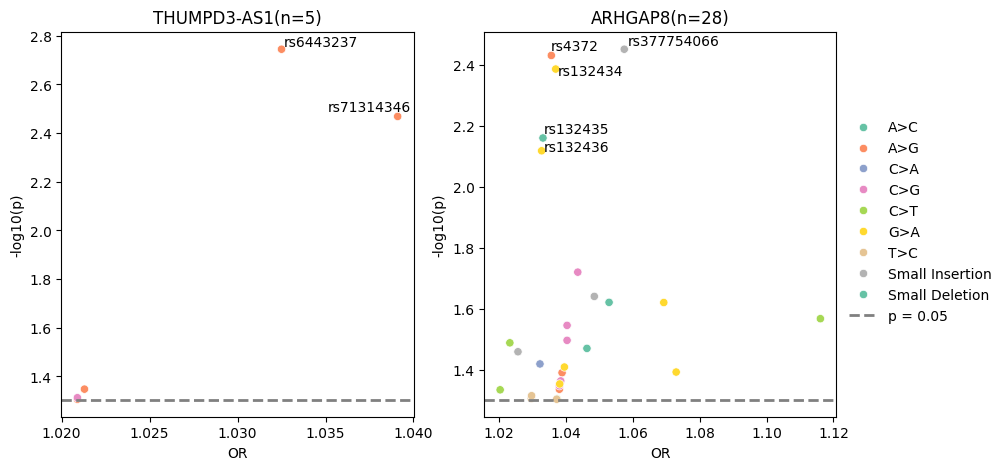

In [126]:
%autoreload
import numpy as np

# modify headers and texts in GWAS_gene_snp_df for visualization
targets = ['ARHGAP8','THUMPD3-AS1','has-miR-485']
GWAS_gene_snp_df['-log10(p)'] = -np.log10(GWAS_gene_snp_df['P'])
GWAS_gene_snp_df['Gene'] = GWAS_gene_snp_df['gene'].apply(lambda gs: ''.join([g if g in targets else '' for g in gs]))
GWAS_gene_snp_df = GWAS_gene_snp_df[GWAS_gene_snp_df['Gene'] != '']
GWAS_gene_snp_df['type'] = GWAS_gene_snp_df['A1'].str.upper() + '>' + GWAS_gene_snp_df['A2'].str.upper()
mymap = {'T>TATGA': 'Small Insertion', 'G>GCT': 'Small Insertion', 
         'CTT>C': 'Small Deletion', 'CTGGTACAGAGCCCAG>C': 'Small Deletion',
         'A>AC': 'Small Insertion'}
GWAS_gene_snp_df['SNP Type'] = GWAS_gene_snp_df['type'].apply(lambda x: mymap.get(x, x))
GWAS_gene_snp_df = GWAS_gene_snp_df.sort_values(by=['SNP Type'])


# set interested ceRNAs to plot
ceRNA_list = ['THUMPD3-AS1', 'ARHGAP8']
# set the output file
out_fn = 'GWAS.pdf'
# plot the gene GWAS SNP hits
cernatax.plot_gene_GWAS_SNP(GWAS_gene_snp_df, gene_count, ceRNA_list, out_fn)